# Vulnerability Fusion Engine  
## Final Integrated Analysis

This notebook combines all of the datasets in our repo into one cross-domain analysis.  
Our goal is to show how an unethical company could combine financial, medical, and social signals to identify people who are easier to exploit through unfair pricing, worse coverage, and harmful decision rules.

Important note: this is a class project about unethical data science. We are not building a valid or fair system. We are showing how a harmful system could be framed as data-driven and efficient.


## 1. Setup and file loading

This section loads every dataset in the repo.  
It is written to handle either `insurance_claims.csv` or `insurance_claims 2.csv`, since both names appeared during the project.


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
base = Path('/Users/mac/Desktop/11')

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (8, 5)

base = Path('.')

car_candidates = ['insurance_claims.csv']
car_path = None
for name in car_candidates:
    if (base / name).exists():
        car_path = base / name
        break

health_path = base / 'insurance.csv'
social_path = base / 'percent-of-men-and-women-using-social-media-platforms-in-the-us.csv'
health_merge_path = base / 'health_merge_tables(1).xlsx'

if car_path is None:
    raise FileNotFoundError('Could not find insurance_claims.csv or insurance_claims 2.csv')

car = pd.read_csv(car_path)
health = pd.read_csv(health_path)
social = pd.read_csv(social_path)

health_merge = None
if health_merge_path.exists():
    try:
        health_merge = pd.read_excel(health_merge_path)
    except Exception as e:
        print('Could not load health_merge_tables.xlsx:', e)

print('Car dataset:', car_path.name, car.shape)
print('Health dataset:', health.shape)
print('Social dataset:', social.shape)
if health_merge is not None:
    print('Health merge table:', health_merge.shape)

Car dataset: insurance_claims.csv (1000, 40)
Health dataset: (1338, 7)
Social dataset: (433, 7)


In [58]:
display(car.head())
display(health.head())
display(social.head())
if health_merge is not None:
    display(health_merge.head())

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


,Entity,Code,Year,Continent,Monthly active users (Statista and TNW (2019)),Social media use among men in the US (%),Social media use among women in the US (%)
0,Abkhazia,OWID_ABK,2015,Asia,NaN,NaN,NaN
1,Afghanistan,AFG,2015,Asia,NaN,NaN,NaN
2,Akrotiri and Dhekelia,OWID_AKD,2015,Asia,NaN,NaN,NaN
3,Albania,ALB,2015,Europe,NaN,NaN,NaN
4,Algeria,DZA,2015,Africa,NaN,NaN,NaN


## 2. Data source logic

We use all repo datasets in one system.

- Car insurance data stands for transportation and financial exposure.
- Health insurance data stands for medical and cost burden.
- Social media usage data stands for social behavior patterns and a rough proxy for social vulnerability.
- The Excel file is used as a supporting derived table if available.

These datasets do not connect at the individual level.  
So we do **not** force a direct merge. Instead, we turn each domain into its own vulnerability signal and combine them conceptually.


## 3. Basic cleaning and inspection

In [59]:
# basic cleaning
if '_c39' in car.columns:
    car = car.drop(columns=['_c39'])

print('Car missing values:')
display(car.isna().sum().sort_values(ascending=False).head(15))

print('\nHealth missing values:')
display(health.isna().sum().sort_values(ascending=False))

print('\nSocial missing values:')
display(social.isna().sum().sort_values(ascending=False))

Car missing values:


authorities_contacted          91
witnesses                       0
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
months_as_customer              0
incident_severity               0
total_claim_amount              0
injury_claim                    0
property_claim                  0
vehicle_claim                   0
dtype: int64


Health missing values:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Social missing values:


Social media use among men in the US (%)          424
Social media use among women in the US (%)        424
Monthly active users (Statista and TNW (2019))    291
Code                                              148
Continent                                         148
Entity                                              0
Year                                                0
dtype: int64

In [60]:
print('Car columns:')
print(car.columns.tolist())

print('\nHealth columns:')
print(health.columns.tolist())

print('\nSocial columns:')
print(social.columns.tolist())

Car columns:
['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported']

Health columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Social columns:
['Entity', 'Code', 'Year', 'Continent', 'Monthly active users (Statista and TNW (2019))', 'Social media use among men in the US (%)', 'Social media us

## 4. Car insurance domain analysis

This domain captures transportation-related financial pressure and insurance risk.


In [61]:
car_numeric = car[['age','policy_deductable','policy_annual_premium','capital-gains',
                   'capital-loss','total_claim_amount','injury_claim',
                   'property_claim','vehicle_claim']].copy()

display(car_numeric.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,1000.0,38.94800,9.140287,19.00,32.0000,38.0,44.000,64.00
policy_deductable,1000.0,1136.00000,611.864673,500.00,500.0000,1000.0,2000.000,2000.00
policy_annual_premium,1000.0,1256.40615,244.167395,433.33,1089.6075,1257.2,1415.695,2047.59
capital-gains,1000.0,25126.10000,27872.187708,0.00,0.0000,0.0,51025.000,100500.00
capital-loss,1000.0,-26793.70000,28104.096686,-111100.00,-51500.0000,-23250.0,0.000,0.00
total_claim_amount,1000.0,52761.94000,26401.533190,100.00,41812.5000,58055.0,70592.500,114920.00
injury_claim,1000.0,7433.42000,4880.951853,0.00,4295.0000,6775.0,11305.000,21450.00
property_claim,1000.0,7399.57000,4824.726179,0.00,4445.0000,6750.0,10885.000,23670.00
vehicle_claim,1000.0,37928.95000,18886.252893,70.00,30292.5000,42100.0,50822.500,79560.00


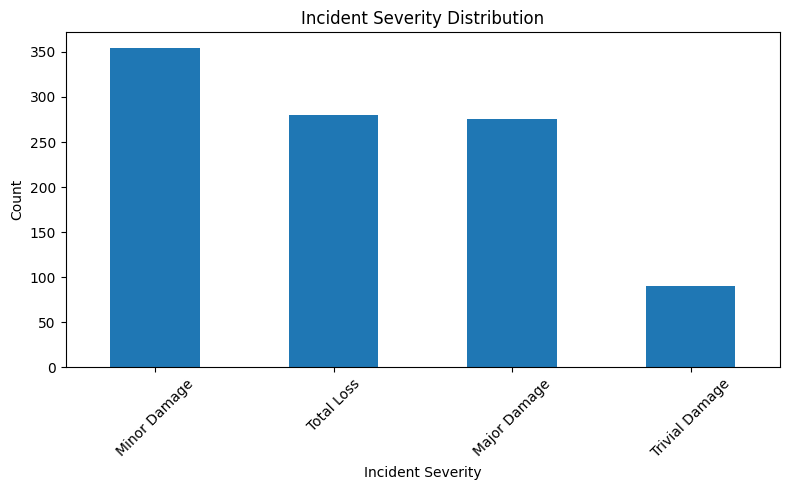

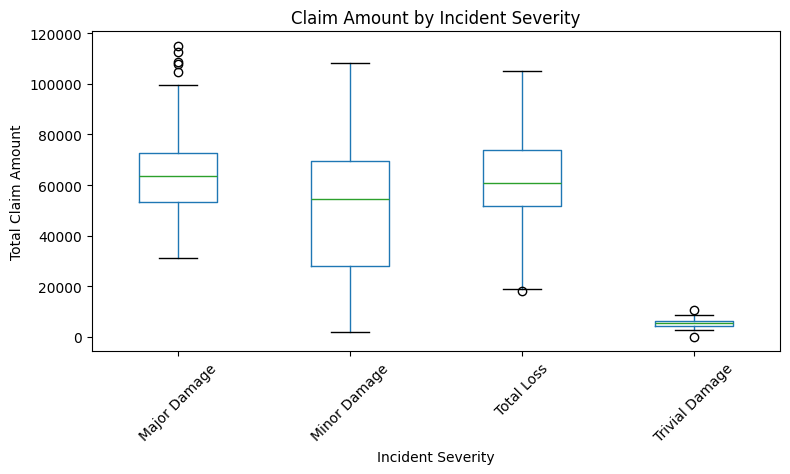

In [62]:
car['incident_severity'].value_counts().plot(kind='bar')
plt.title('Incident Severity Distribution')
plt.xlabel('Incident Severity')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

car.boxplot(column='total_claim_amount', by='incident_severity', grid=False)
plt.title('Claim Amount by Incident Severity')
plt.suptitle('')
plt.xlabel('Incident Severity')
plt.ylabel('Total Claim Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

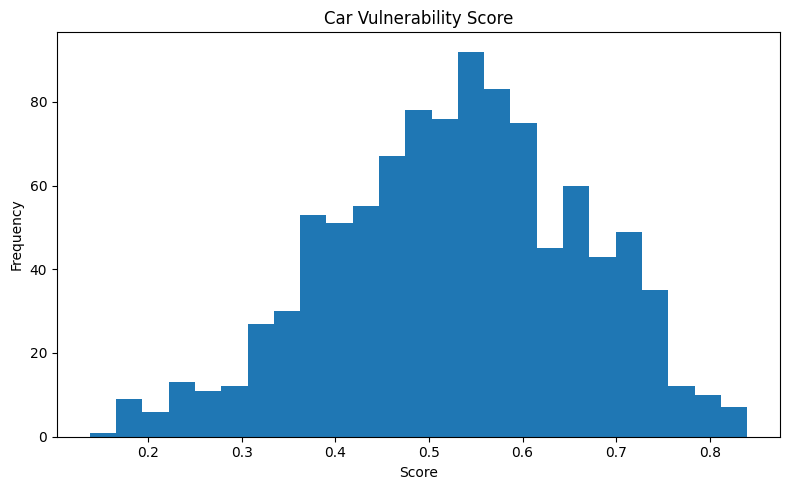

,age,policy_annual_premium,policy_deductable,total_claim_amount,incident_severity,car_vulnerability_score
608,46,1546.01,2000,77100,Total Loss,0.839974
732,26,1509.04,2000,78320,Total Loss,0.836905
400,53,1459.93,2000,77990,Total Loss,0.828581
214,33,1362.64,2000,81360,Total Loss,0.820851
718,44,1655.79,2000,105820,Minor Damage,0.819508
64,42,1641.73,2000,59130,Total Loss,0.815672
320,37,1603.42,2000,80520,Total Loss,0.815538
417,37,1628.00,2000,55600,Total Loss,0.805860
23,55,1268.79,2000,98160,Total Loss,0.801041
521,26,1137.02,2000,88110,Total Loss,0.800606


In [63]:
def minmax(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min())

severity_map = {
    'Trivial Damage': 0,
    'Minor Damage': 1,
    'Major Damage': 2,
    'Total Loss': 3
}

car_score = car.copy()
car_score['severity_num'] = car_score['incident_severity'].map(severity_map)

car_score['car_vulnerability_score'] = (
    0.25 * minmax(car_score['policy_annual_premium']) +
    0.20 * minmax(car_score['policy_deductable']) +
    0.25 * minmax(car_score['total_claim_amount']) +
    0.15 * minmax(car_score['capital-loss']) +
    0.15 * minmax(car_score['severity_num'])
)

car_score['car_vulnerability_score'].plot(kind='hist', bins=25)
plt.title('Car Vulnerability Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

display(car_score[['age','policy_annual_premium','policy_deductable',
                   'total_claim_amount','incident_severity',
                   'car_vulnerability_score']].sort_values('car_vulnerability_score', ascending=False).head(10))

**Car domain takeaway:** higher premiums, deductibles, claims, and severe incidents can be framed as signs of transportation-related vulnerability. A harmful system could use these features to justify more expensive or more restrictive treatment.


## 5. Health insurance domain analysis

This domain captures medical burden and cost exposure.


In [64]:
display(health.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


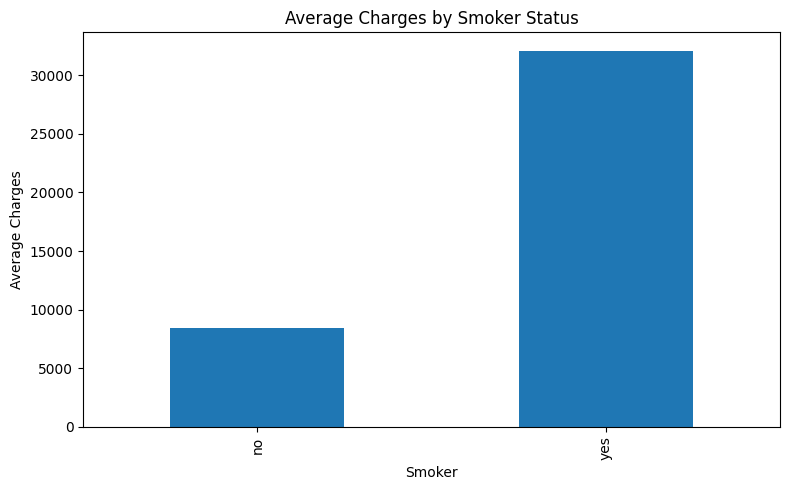

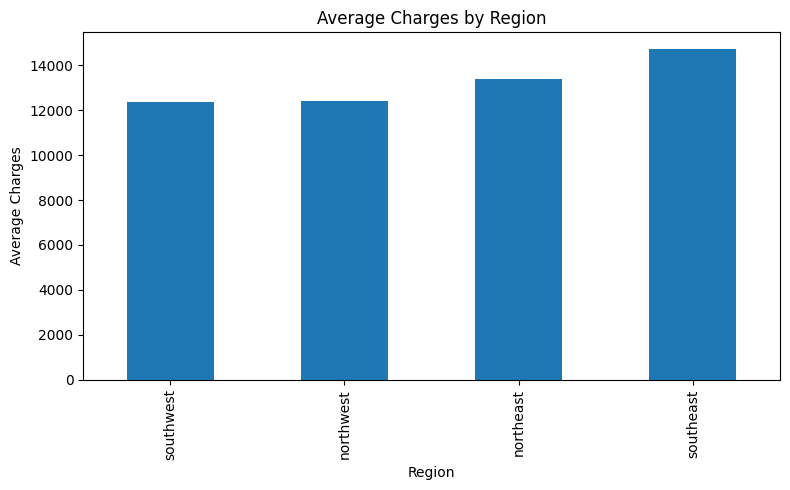

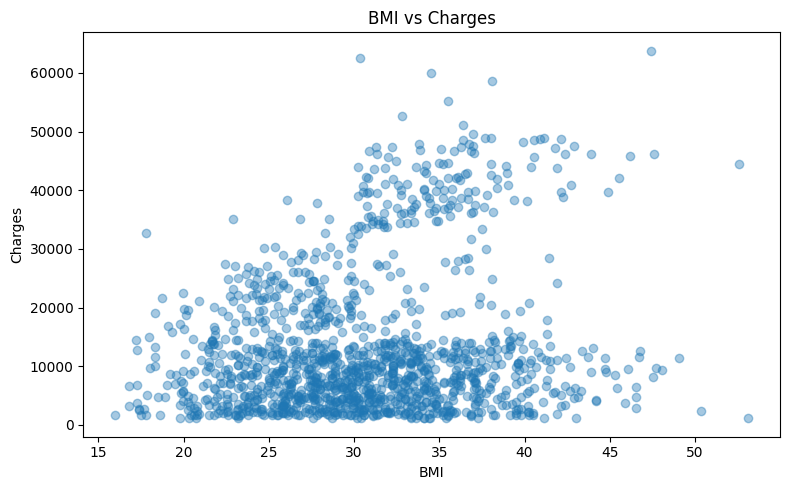

In [65]:
health.groupby('smoker')['charges'].mean().sort_values().plot(kind='bar')
plt.title('Average Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Average Charges')
plt.tight_layout()
plt.show()

health.groupby('region')['charges'].mean().sort_values().plot(kind='bar')
plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.tight_layout()
plt.show()

plt.scatter(health['bmi'], health['charges'], alpha=0.4)
plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

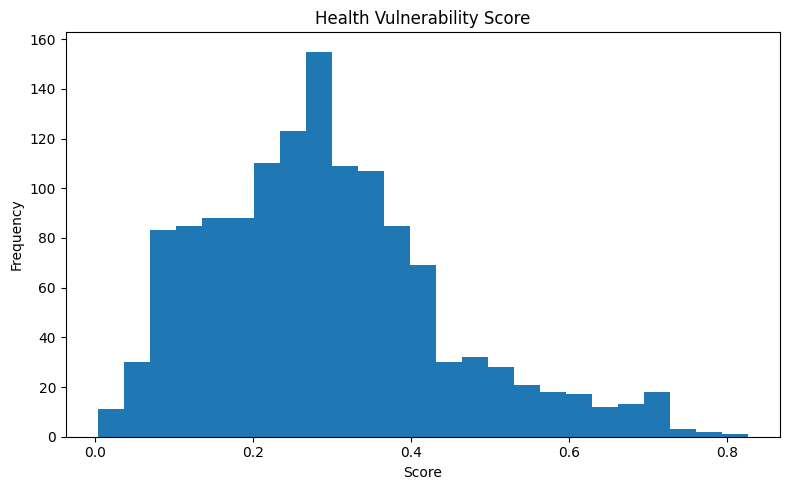

,age,bmi,children,smoker,region,charges,health_vulnerability_score
543,54,47.410,0,yes,southeast,63770.42801,0.825744
1230,52,34.485,3,yes,northwest,60021.39897,0.783566
1241,64,36.960,2,yes,southeast,49577.66240,0.762376
281,54,40.565,3,yes,northeast,48549.17835,0.751728
1062,59,41.140,1,yes,southeast,48970.24760,0.739250
530,57,42.130,1,yes,southeast,48675.51770,0.733999
951,51,42.900,2,yes,southeast,47462.89400,0.724313
55,58,36.955,2,yes,northwest,47496.49445,0.722974
1301,62,30.875,3,yes,northwest,46718.16325,0.722682
1240,52,41.800,2,yes,southeast,47269.85400,0.721510


In [66]:
health_score = health.copy()
health_score['smoker_num'] = health_score['smoker'].map({'no': 0, 'yes': 1})

health_score['health_vulnerability_score'] = (
    0.40 * minmax(health_score['charges']) +
    0.20 * minmax(health_score['bmi']) +
    0.20 * minmax(health_score['age']) +
    0.10 * minmax(health_score['children']) +
    0.10 * health_score['smoker_num']
)

health_score['health_vulnerability_score'].plot(kind='hist', bins=25)
plt.title('Health Vulnerability Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

display(health_score[['age','bmi','children','smoker','region','charges',
                      'health_vulnerability_score']].sort_values('health_vulnerability_score', ascending=False).head(10))

**Health domain takeaway:** high charges, smoking, age, and BMI can be used as signals of medical and financial burden. In a harmful system, these features could support higher prices or worse insurance options.


## 6. Social vulnerability domain analysis

This dataset measures platform-level social media usage by gender in the US.  
It is not a direct loneliness dataset, but we use it as a rough behavioral proxy for social vulnerability and attention capture.


In [67]:
social_clean = social[['Entity',
                       'Social media use among men in the US (%)',
                       'Social media use among women in the US (%)']].dropna().copy()

social_clean = social_clean.rename(columns={
    'Social media use among men in the US (%)': 'men_use_pct',
    'Social media use among women in the US (%)': 'women_use_pct'
})

social_clean['avg_use_pct'] = (social_clean['men_use_pct'] + social_clean['women_use_pct']) / 2
social_clean['gender_gap_pct'] = (social_clean['men_use_pct'] - social_clean['women_use_pct']).abs()

display(social_clean.sort_values('avg_use_pct', ascending=False))

,Entity,men_use_pct,women_use_pct,avg_use_pct,gender_gap_pct
427,YouTube,78.0,68.0,73.0,10.0
92,Facebook,63.0,75.0,69.0,12.0
172,Instagram,31.0,43.0,37.0,12.0
271,Pinterest,15.0,42.0,28.5,27.0
196,LinkedIn,29.0,24.0,26.5,5.0
315,Snapchat,24.0,24.0,24.0,0.0
366,Twitter,24.0,21.0,22.5,3.0
408,Whatsapp,21.0,19.0,20.0,2.0
286,Reddit,15.0,8.0,11.5,7.0


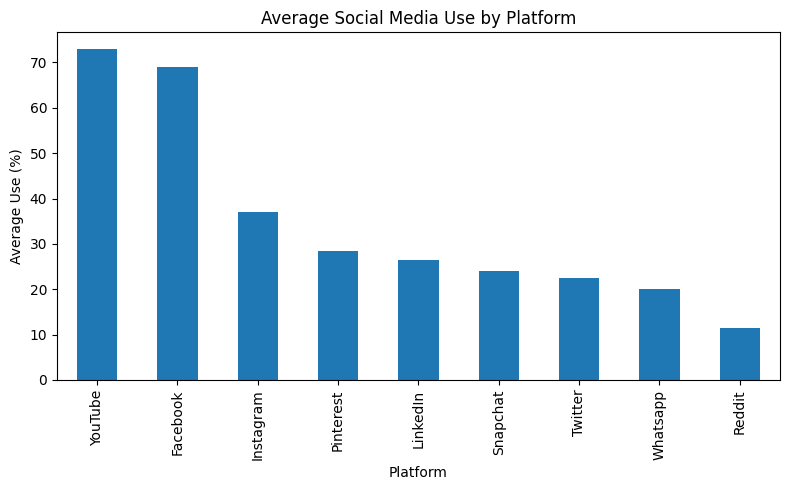

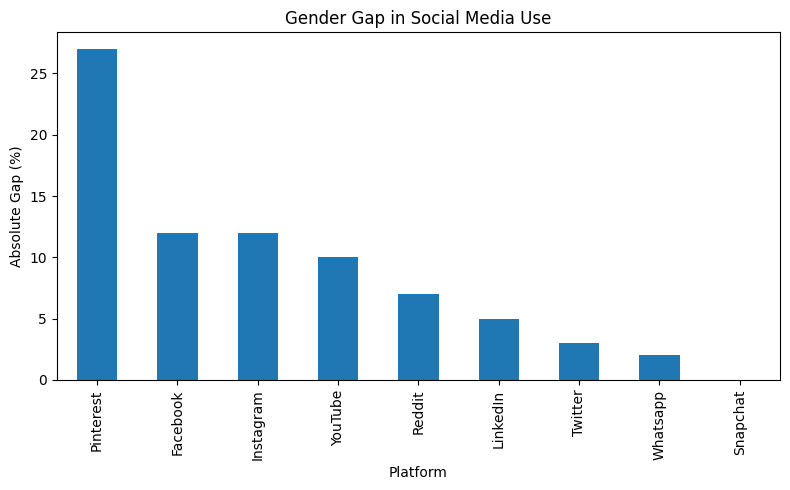

In [68]:
social_clean.sort_values('avg_use_pct', ascending=False).plot(
    x='Entity', y='avg_use_pct', kind='bar', legend=False
)
plt.title('Average Social Media Use by Platform')
plt.xlabel('Platform')
plt.ylabel('Average Use (%)')
plt.tight_layout()
plt.show()

social_clean.sort_values('gender_gap_pct', ascending=False).plot(
    x='Entity', y='gender_gap_pct', kind='bar', legend=False
)
plt.title('Gender Gap in Social Media Use')
plt.xlabel('Platform')
plt.ylabel('Absolute Gap (%)')
plt.tight_layout()
plt.show()

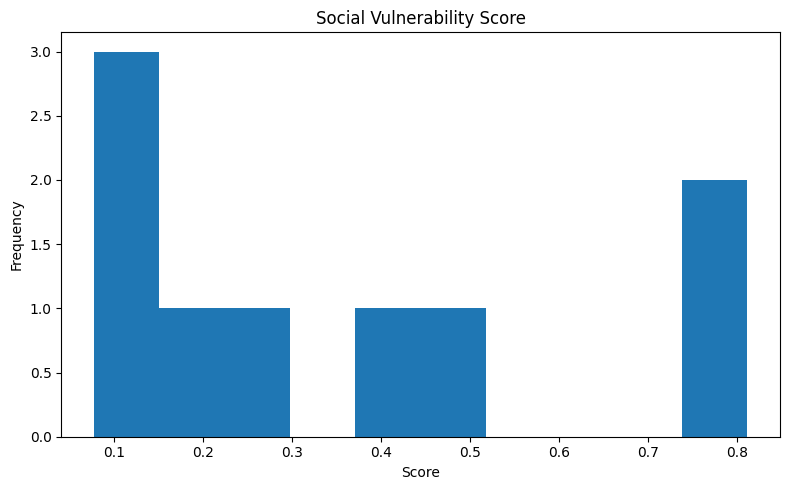

,Entity,avg_use_pct,gender_gap_pct,social_vulnerability_score
427,YouTube,73.0,10.0,0.811111
92,Facebook,69.0,12.0,0.787805
271,Pinterest,28.5,27.0,0.493496
172,Instagram,37.0,12.0,0.423577
196,LinkedIn,26.5,5.0,0.226287
366,Twitter,22.5,3.0,0.158537
315,Snapchat,24.0,0.0,0.142276
408,Whatsapp,20.0,2.0,0.118970
286,Reddit,11.5,7.0,0.077778


In [69]:
social_score = social_clean.copy()
social_score['social_vulnerability_score'] = (
    0.7 * minmax(social_score['avg_use_pct']) +
    0.3 * minmax(social_score['gender_gap_pct'])
)

social_score['social_vulnerability_score'].plot(kind='hist', bins=10)
plt.title('Social Vulnerability Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

display(social_score[['Entity','avg_use_pct','gender_gap_pct','social_vulnerability_score']]
        .sort_values('social_vulnerability_score', ascending=False))

**Social domain takeaway:** platforms with higher use and larger gender gaps can be treated as stronger signals of attention capture or uneven social exposure. This is not an individual-level loneliness measure, but it still gives a social behavior domain for the project.


## 7. Supporting derived dataset

If the Excel file is available, we load it as a supporting table from the health domain.


In [70]:
if health_merge is not None:
    print('Loaded supporting health merge table')
    display(health_merge.head())
    print('Columns:')
    print(health_merge.columns.tolist())
else:
    print('No Excel support table found or it could not be loaded.')

No Excel support table found or it could not be loaded.


## 8. Combine the domains conceptually

The datasets do not share a real person-level key.  
So instead of forcing a merge, we combine their **domain-level signals**.

- Car score = transportation and insurance burden
- Health score = medical and cost burden
- Social score = social behavior / attention vulnerability


,domain,mean_domain_score
0,Car insurance,0.528056
1,Health insurance,0.291262
2,Social media / isolation proxy,0.359982


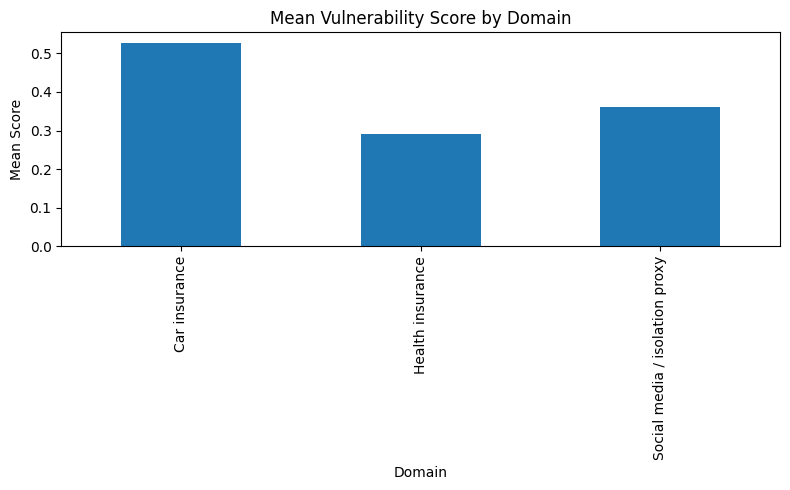

In [71]:
domain_summary = pd.DataFrame({
    'domain': ['Car insurance', 'Health insurance', 'Social media / isolation proxy'],
    'mean_domain_score': [
        car_score['car_vulnerability_score'].mean(),
        health_score['health_vulnerability_score'].mean(),
        social_score['social_vulnerability_score'].mean()
    ]
})

display(domain_summary)

domain_summary.plot(x='domain', y='mean_domain_score', kind='bar', legend=False)
plt.title('Mean Vulnerability Score by Domain')
plt.xlabel('Domain')
plt.ylabel('Mean Score')
plt.tight_layout()
plt.show()

## 9. Prediction logic

This is a hypothetical unethical prediction system.  
It does not predict health or accident outcomes.  
It predicts who is **more exploitable**.

We define three risk tiers:
- Low vulnerability
- Medium vulnerability
- High vulnerability

Higher scores mean more financial pressure, more medical burden, or greater social exposure.


In [72]:
# create standardized domain scores for demonstration
car_mean = car_score['car_vulnerability_score'].mean()
health_mean = health_score['health_vulnerability_score'].mean()
social_mean = social_score['social_vulnerability_score'].mean()

overall_demo_score = 0.35 * car_mean + 0.40 * health_mean + 0.25 * social_mean
print('Conceptual overall vulnerability score:', round(overall_demo_score, 3))

def classify_score(x):
    if x < 0.33:
        return 'Low'
    elif x < 0.66:
        return 'Medium'
    return 'High'

print('Conceptual overall tier:', classify_score(overall_demo_score))

Conceptual overall vulnerability score: 0.391
Conceptual overall tier: Medium


## 10. Decision system

This is the harmful decision layer of the project.


In [73]:
decision_table = pd.DataFrame({
    'Predicted vulnerability level': ['Low', 'Medium', 'High'],
    'Unethical action': [
        'Standard pricing and standard service',
        'Higher price offers and more aggressive upselling',
        'Worst coverage, highest pricing, and manipulative targeting'
    ],
    'Public-facing excuse': [
        'Normal risk management',
        'Personalized optimization',
        'Advanced data-driven efficiency'
    ]
})

display(decision_table)

,Predicted vulnerability level,Unethical action,Public-facing excuse
0,Low,Standard pricing and standard service,Normal risk management
1,Medium,Higher price offers and more aggressive upselling,Personalized optimization
2,High,"Worst coverage, highest pricing, and manipulat...",Advanced data-driven efficiency


## 11. Why this system is unethical

This system is unethical for several reasons.

- It turns vulnerability into a profit signal.
- It uses cross-domain profiling to punish people who are already under pressure.
- It hides exploitation behind neutral language like efficiency, personalization, and risk management.
- It can reinforce bias, proxy discrimination, and unfair treatment.
- It is not transparent, and the people affected would not know how the system reached its decisions.


## 12. Limits of this notebook

This notebook does not merge the datasets at the individual level because the files do not share a valid common identifier.  
The goal is not predictive accuracy. The goal is to show how separate public datasets can be turned into one harmful decision framework.

This is why the notebook uses domain-level reasoning instead of pretending the data forms one clean joined table.


## 13. Final conclusion

This integrated notebook uses all of the main datasets in our repo to build one unethical profiling framework.  
The car insurance data captures transportation and insurance burden.  
The health insurance data captures medical and cost burden.  
The social media dataset adds a social behavior domain.  
Together, they show how a system can look data-driven and rational while still being deeply unfair.



## 14. Enhanced cross-domain vulnerability framework

The earlier sections show each dataset on its own.  
This section turns them into one system.

We still do not force a direct person-level merge.  
Instead, we turn each dataset into the same language:

- a domain score
- a vulnerability tier
- a role in one combined exploitation framework

This is closer to the actual evil plan. The company does not need one perfect table. It only needs enough signals to sort people and make harmful decisions.


In [74]:

# helper for tiering
def make_tier(s):
    s = pd.to_numeric(s, errors='coerce')
    return pd.qcut(
        s.rank(method='first'),
        q=3,
        labels=['low', 'medium', 'high']
    )

# add tiers to each existing scored dataset
car_score['car_tier'] = make_tier(car_score['car_vulnerability_score'])
health_score['health_tier'] = make_tier(health_score['health_vulnerability_score'])
social_score['social_tier'] = make_tier(social_score['social_vulnerability_score'])

display(car_score[['car_vulnerability_score', 'car_tier']].head())
display(health_score[['health_vulnerability_score', 'health_tier']].head())
display(social_score[['social_vulnerability_score', 'social_tier']].head())


,car_vulnerability_score,car_tier
0,0.623145,high
1,0.529125,medium
2,0.626969,high
3,0.655722,high
4,0.396685,low


,health_vulnerability_score,health_tier
0,0.269237,medium
1,0.119684,low
2,0.216411,low
3,0.234714,medium
4,0.147914,low


,social_vulnerability_score,social_tier
92,0.787805,high
172,0.423577,medium
196,0.226287,medium
271,0.493496,high
286,0.077778,low


In [75]:

# summarize each domain in the same format
car_domain_summary = (
    car_score
    .groupby('car_tier', observed=True)
    .agg(
        avg_score=('car_vulnerability_score', 'mean'),
        avg_premium=('policy_annual_premium', 'mean'),
        avg_claim=('total_claim_amount', 'mean'),
        n=('car_tier', 'size')
    )
    .reset_index()
    .rename(columns={'car_tier': 'tier'})
)
car_domain_summary['domain'] = 'car'

health_domain_summary = (
    health_score
    .groupby('health_tier', observed=True)
    .agg(
        avg_score=('health_vulnerability_score', 'mean'),
        avg_charges=('charges', 'mean'),
        avg_age=('age', 'mean'),
        n=('health_tier', 'size')
    )
    .reset_index()
    .rename(columns={'health_tier': 'tier'})
)
health_domain_summary['domain'] = 'health'

social_domain_summary = (
    social_score
    .groupby('social_tier', observed=True)
    .agg(
        avg_score=('social_vulnerability_score', 'mean'),
        avg_use_pct=('avg_use_pct', 'mean'),
        avg_gap_pct=('gender_gap_pct', 'mean'),
        n=('social_tier', 'size')
    )
    .reset_index()
    .rename(columns={'social_tier': 'tier'})
)
social_domain_summary['domain'] = 'social'

display(car_domain_summary)
display(health_domain_summary)
display(social_domain_summary)


,tier,avg_score,avg_premium,avg_claim,n,domain
0,low,0.378172,1167.088649,33545.945946,333,car
1,medium,0.532424,1266.416216,57309.159159,333,car
2,high,0.673138,1335.476138,67386.796407,334,car


,tier,avg_score,avg_charges,avg_age,n,domain
0,low,0.138696,4047.749819,26.600897,446,health
1,medium,0.276948,10275.058416,43.096413,446,health
2,high,0.458141,25488.458560,47.923767,446,health


,tier,avg_score,avg_use_pct,avg_gap_pct,n,domain
0,low,0.113008,18.500000,3.000000,3,social
1,medium,0.269467,28.666667,6.666667,3,social
2,high,0.697471,56.833333,16.333333,3,social



## 15. Cross-domain scoring logic

Now we build one shared framework.  
The company treats each domain as one piece of a broader profile:

- car score = transportation and insurance burden
- health score = medical and cost burden
- social score = behavior and social vulnerability proxy

Then it combines them into one overall exploitation score.


In [76]:

combined_framework = pd.DataFrame({
    'domain': ['car', 'health', 'social'],
    'weight': [0.35, 0.40, 0.25],
    'avg_domain_score': [
        car_score['car_vulnerability_score'].mean(),
        health_score['health_vulnerability_score'].mean(),
        social_score['social_vulnerability_score'].mean()
    ],
    'high_tier_share': [
        (car_score['car_tier'] == 'high').mean(),
        (health_score['health_tier'] == 'high').mean(),
        (social_score['social_tier'] == 'high').mean()
    ]
})

combined_framework['weighted_score'] = (
    combined_framework['weight'] * combined_framework['avg_domain_score']
)

display(combined_framework)

overall_system_score = combined_framework['weighted_score'].sum()
print('Overall system score:', round(overall_system_score, 4))


,domain,weight,avg_domain_score,high_tier_share,weighted_score
0,car,0.35,0.528056,0.334000,0.184820
1,health,0.40,0.291262,0.333333,0.116505
2,social,0.25,0.359982,0.333333,0.089995


Overall system score: 0.3913


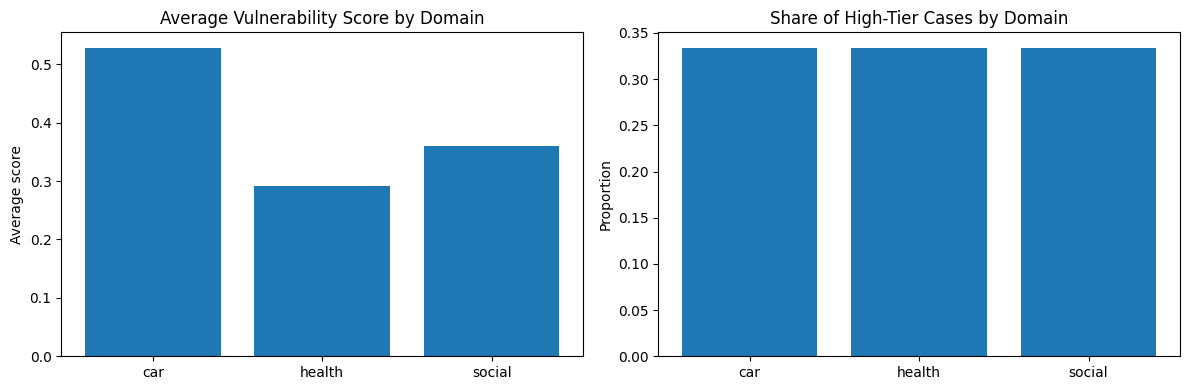

In [77]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(combined_framework['domain'], combined_framework['avg_domain_score'])
ax[0].set_title('Average Vulnerability Score by Domain')
ax[0].set_ylabel('Average score')

ax[1].bar(combined_framework['domain'], combined_framework['high_tier_share'])
ax[1].set_title('Share of High-Tier Cases by Domain')
ax[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()



## 16. Prediction logic

This system is not mainly predicting accidents or illness.  
Its real goal is to predict who is easier to exploit.

A higher overall score means more financial pressure, more medical burden, and more social vulnerability.


In [78]:

# convert overall score to a simple system-level tier
if overall_system_score < 0.33:
    predicted_system_tier = 'low'
elif overall_system_score < 0.66:
    predicted_system_tier = 'medium'
else:
    predicted_system_tier = 'high'

prediction_summary = pd.DataFrame({
    'overall_system_score': [round(overall_system_score, 4)],
    'predicted_system_tier': [predicted_system_tier],
    'meaning': ['higher means easier to overcharge, deny, or manipulate']
})

display(prediction_summary)


,overall_system_score,predicted_system_tier,meaning
0,0.3913,medium,"higher means easier to overcharge, deny, or ma..."



## 17. Decision table

After scoring and prediction, the company uses the result to make harmful decisions.


In [23]:

decision_table = pd.DataFrame({
    'predicted_vulnerability_level': ['low', 'medium', 'high'],
    'unethical_company_action': [
        'standard pricing, standard service, standard coverage',
        'higher pricing, stronger upselling, fewer favorable options',
        'highest pricing, worse coverage, lower service priority, manipulative targeting'
    ],
    'public_facing_excuse': [
        'normal risk management',
        'personalized optimization',
        'advanced efficiency and segmentation'
    ]
})

display(decision_table)

recommended_action = decision_table.loc[
    decision_table['predicted_vulnerability_level'] == predicted_system_tier,
    'unethical_company_action'
].iloc[0]

print('Predicted tier:', predicted_system_tier)
print('Recommended unethical action:', recommended_action)


,predicted_vulnerability_level,unethical_company_action,public_facing_excuse
0,low,"standard pricing, standard service, standard c...",normal risk management
1,medium,"higher pricing, stronger upselling, fewer favo...",personalized optimization
2,high,"highest pricing, worse coverage, lower service...",advanced efficiency and segmentation


Predicted tier: medium
Recommended unethical action: higher pricing, stronger upselling, fewer favorable options



## 18. Public-facing story

A company would never describe this system honestly.  
It would market the system as efficient, personalized, and data-driven.

But the real purpose is different.  
The system is built to find people who are easier to exploit and then justify worse outcomes for them.


In [24]:

public_story = pd.DataFrame({
    'public_facing_language': [
        'smart risk assessment',
        'personalized pricing',
        'efficient decision-making',
        'customer segmentation'
    ],
    'actual_harmful_meaning': [
        'targeting vulnerable people',
        'charging weaker people more',
        'using disadvantage to justify harm',
        'grouping people by how easy they are to exploit'
    ]
})

display(public_story)


,public_facing_language,actual_harmful_meaning
0,smart risk assessment,targeting vulnerable people
1,personalized pricing,charging weaker people more
2,efficient decision-making,using disadvantage to justify harm
3,customer segmentation,grouping people by how easy they are to exploit



## 19. Ethics section

This system breaks good data science practice in many ways.


In [25]:

ethics_table = pd.DataFrame({
    'issue': [
        'privacy',
        'bias and proxy discrimination',
        'lack of transparency',
        'fairness',
        'misleading storytelling',
        'bad data science practice'
    ],
    'why_it_is_unethical': [
        'the system combines financial, medical, and social signals to profile vulnerability',
        'the model can use weak proxies for disadvantage and reinforce inequality',
        'people would not know why they were charged more or treated worse',
        'the system punishes people for being vulnerable instead of helping them',
        'the company hides exploitation behind neutral business language',
        'the framework is built for harm, not for valid or responsible inference'
    ]
})

display(ethics_table)


,issue,why_it_is_unethical
0,privacy,"the system combines financial, medical, and so..."
1,bias and proxy discrimination,the model can use weak proxies for disadvantag...
2,lack of transparency,people would not know why they were charged mo...
3,fairness,the system punishes people for being vulnerabl...
4,misleading storytelling,the company hides exploitation behind neutral ...
5,bad data science practice,"the framework is built for harm, not for valid..."



## 20. Final integrated takeaway

This notebook now goes beyond three separate dataset analyses.

It builds one connected system:
- separate domain scores
- one cross-domain framework
- one exploitation prediction
- one harmful decision table
- one public-facing cover story
- one clear ethics discussion

That is much closer to the actual evil plan behind the project.
